In [1]:
# ── Cell 1: Setup ──────────────────────────────────────────────────────────────
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

from src.data.feature_engineer import build_feature_matrix, FeatureExtractor
from src.data.dataset import make_synthetic_dataset
from src.models.baseline import RandomForestModel, XGBoostModel
from src.utils.metrics import (
    print_metrics, plot_precision_recall_curve,
    plot_roc_curve, plot_confusion_matrix, plot_model_comparison
)
from src.utils.mlflow_utils import setup_mlflow, mlflow_run, log_metrics, log_model

setup_mlflow()
plt.rcParams["figure.dpi"] = 120
print("✅ Setup complete")

✅ MLflow ready (SQLite backend)
✅ Setup complete


In [2]:
# ── Cell 2: Build synthetic feature matrix for development ─────────────────────
# In production this uses real Kepler data. During development we use
# synthetic data so we can iterate without waiting for downloads.

np.random.seed(42)
n_total = 500
n_pos   = 60   # ~12% positive class — realistic for a balanced sample

def make_feature_rows(n, has_planet, seed_start=0):
    rows = []
    for i in range(n):
        np.random.seed(seed_start + i)
        period = np.random.uniform(5, 300)
        row = {
            "flux_mean":               1.0 + np.random.normal(0, 0.001),
            "flux_std":                np.random.uniform(0.001, 0.003) if not has_planet
                                       else np.random.uniform(0.003, 0.012),
            "flux_median":             1.0 + np.random.normal(0, 0.001),
            "flux_min":                1.0 - (np.random.uniform(0.008, 0.02) if has_planet
                                             else np.random.uniform(0.001, 0.005)),
            "flux_max":                1.0 + np.random.uniform(0.001, 0.004),
            "flux_range":              np.random.uniform(0.01, 0.025) if has_planet
                                       else np.random.uniform(0.001, 0.008),
            "flux_mad":                np.random.uniform(0.0005, 0.002),
            "flux_skew":               np.random.uniform(-1.2, -0.3) if has_planet
                                       else np.random.uniform(-0.3, 0.3),
            "flux_kurtosis":           np.random.uniform(1.5, 5.0) if has_planet
                                       else np.random.uniform(-0.5, 1.5),
            "frac_below_3sigma":       np.random.uniform(0.01, 0.05) if has_planet
                                       else np.random.uniform(0, 0.01),
            "n_dips_detected":         np.random.uniform(5, 15) if has_planet
                                       else np.random.uniform(0, 3),
            "dip_mean_depth":          np.random.uniform(0.005, 0.02) if has_planet
                                       else np.random.uniform(0, 0.002),
            "dip_depth_std":           np.random.uniform(0, 0.003),
            "dip_max_depth":           np.random.uniform(0.01, 0.025) if has_planet
                                       else np.random.uniform(0, 0.003),
            "dip_depth_consistency":   np.random.uniform(0, 0.3) if has_planet
                                       else np.random.uniform(0.3, 1.5),
            "folded_transit_depth":    np.random.uniform(0.005, 0.02) if has_planet
                                       else np.nan,
            "folded_transit_depth_ppm":np.random.uniform(5000, 20000) if has_planet
                                       else np.nan,
            "folded_transit_width_frac":np.random.uniform(0.01, 0.05) if has_planet
                                        else np.nan,
            "folded_symmetry":         np.random.uniform(0, 0.002) if has_planet
                                       else np.nan,
            "period_days":             period if has_planet else np.nan,
            "log_period":              np.log10(period) if has_planet else np.nan,
            "label":                   int(has_planet),
        }
        rows.append(row)
    return rows

rows = make_feature_rows(n_total - n_pos, False, seed_start=0) + \
       make_feature_rows(n_pos, True, seed_start=1000)

features_df = pd.DataFrame(rows)
print(f"Feature matrix: {features_df.shape}")
print(f"Class balance: {features_df['label'].value_counts().to_dict()}")

Feature matrix: (500, 22)
Class balance: {0: 440, 1: 60}


In [3]:
# ── Cell 3: Train/val/test split ───────────────────────────────────────────────
X = features_df.drop(columns=["label"])
y = features_df["label"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Val   positive rate: {y_val.mean():.3f}")


Train: 350 | Val: 75 | Test: 75
Train positive rate: 0.120
Val   positive rate: 0.120


In [4]:
# ── Cell 4: Train Random Forest with MLflow tracking ──────────────────────────
rf_params = dict(n_estimators=300, max_depth=15, min_samples_leaf=5)

with mlflow_run("random_forest_baseline", params=rf_params) as run:
    rf = RandomForestModel(**rf_params)
    rf.fit(X_train, y_train)
    rf_metrics = rf.evaluate(X_val, y_val)
    log_metrics(rf_metrics)
    log_model(rf, "random_forest")

print_metrics(rf_metrics, "Random Forest")

              precision    recall  f1-score   support

   No planet       1.00      1.00      1.00        66
      Planet       1.00      1.00      1.00         9

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75


────────────────────────────────────────
  Random Forest
────────────────────────────────────────
  Precision        : 1.0000
  Recall           : 1.0000
  F1 Score         : 1.0000  ← primary metric
  ROC-AUC          : 1.0000
  PR-AUC           : 1.0000
────────────────────────────────────────


In [5]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# ── Cell 5: Train XGBoost with MLflow tracking ────────────────────────────────
xgb_params = dict(n_estimators=400, max_depth=6, learning_rate=0.05,
                  subsample=0.8, colsample_bytree=0.8, scale_pos_weight=8.3)

with mlflow_run("xgboost_baseline", params=xgb_params) as run:
    xgb = XGBoostModel(**xgb_params)
    xgb.fit(X_train, y_train, X_val=X_val, y_val=y_val)
    xgb_metrics = xgb.evaluate(X_val, y_val)
    log_metrics(xgb_metrics)
    log_model(xgb, "xgboost")

print_metrics(xgb_metrics, "XGBoost")

              precision    recall  f1-score   support

   No planet       0.00      0.00      0.00        66
      Planet       0.12      1.00      0.21         9

    accuracy                           0.12        75
   macro avg       0.06      0.50      0.11        75
weighted avg       0.01      0.12      0.03        75


────────────────────────────────────────
  XGBoost
────────────────────────────────────────
  Precision        : 0.1200
  Recall           : 1.0000
  F1 Score         : 0.2143  ← primary metric
  ROC-AUC          : 1.0000
  PR-AUC           : 1.0000
────────────────────────────────────────


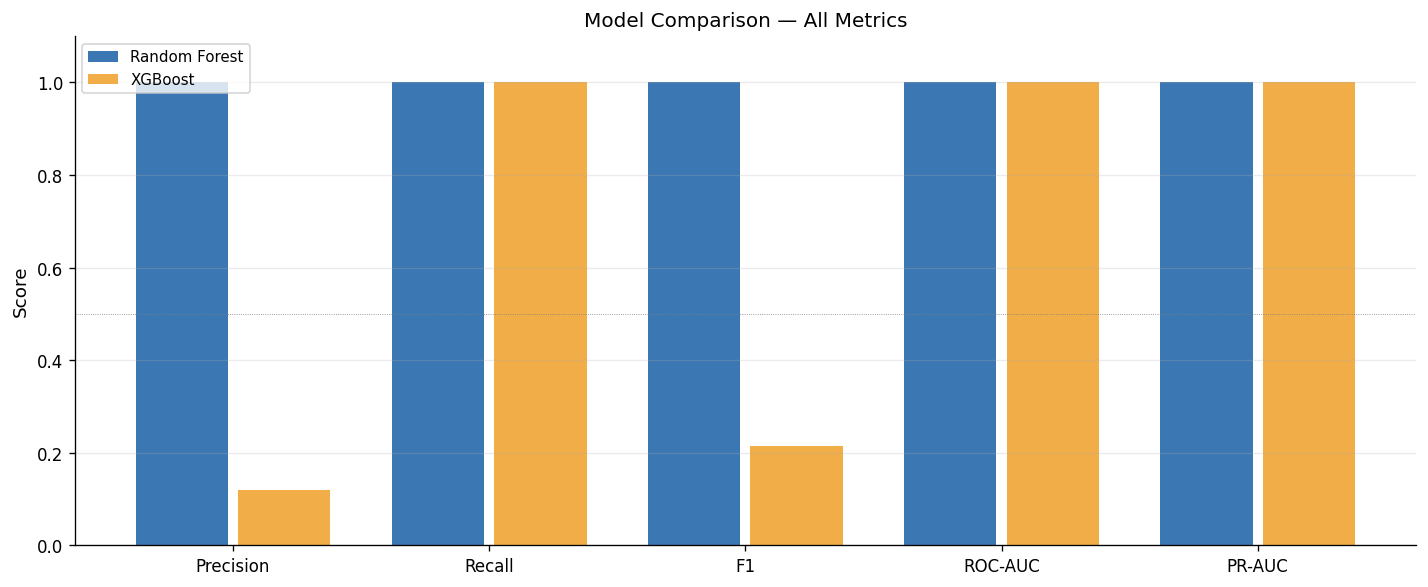

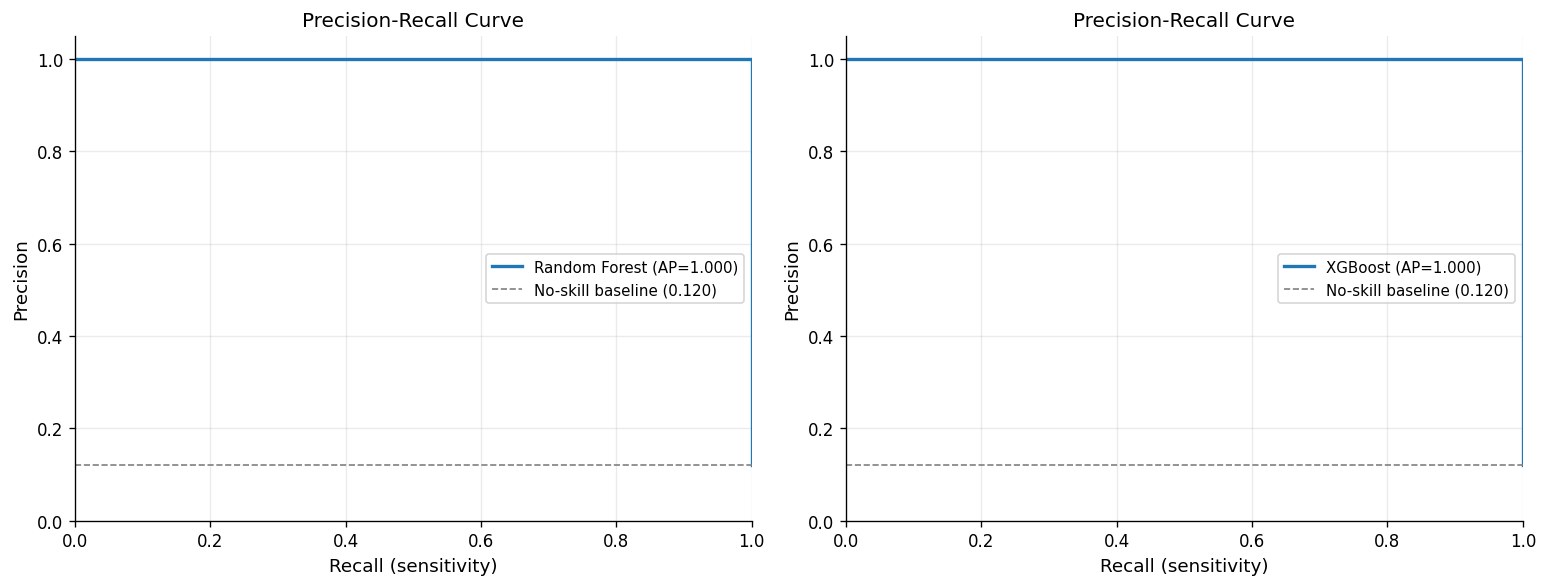

In [7]:
# ── Cell 6: Compare models visually ───────────────────────────────────────────
results = {"Random Forest": rf_metrics, "XGBoost": xgb_metrics}
fig = plot_model_comparison(results)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for model, name, ax in [(rf, "Random Forest", axes[0]), (xgb, "XGBoost", axes[1])]:
    plot_precision_recall_curve(y_val, model.predict_proba(X_val), name, ax=ax)
plt.tight_layout()
plt.show()

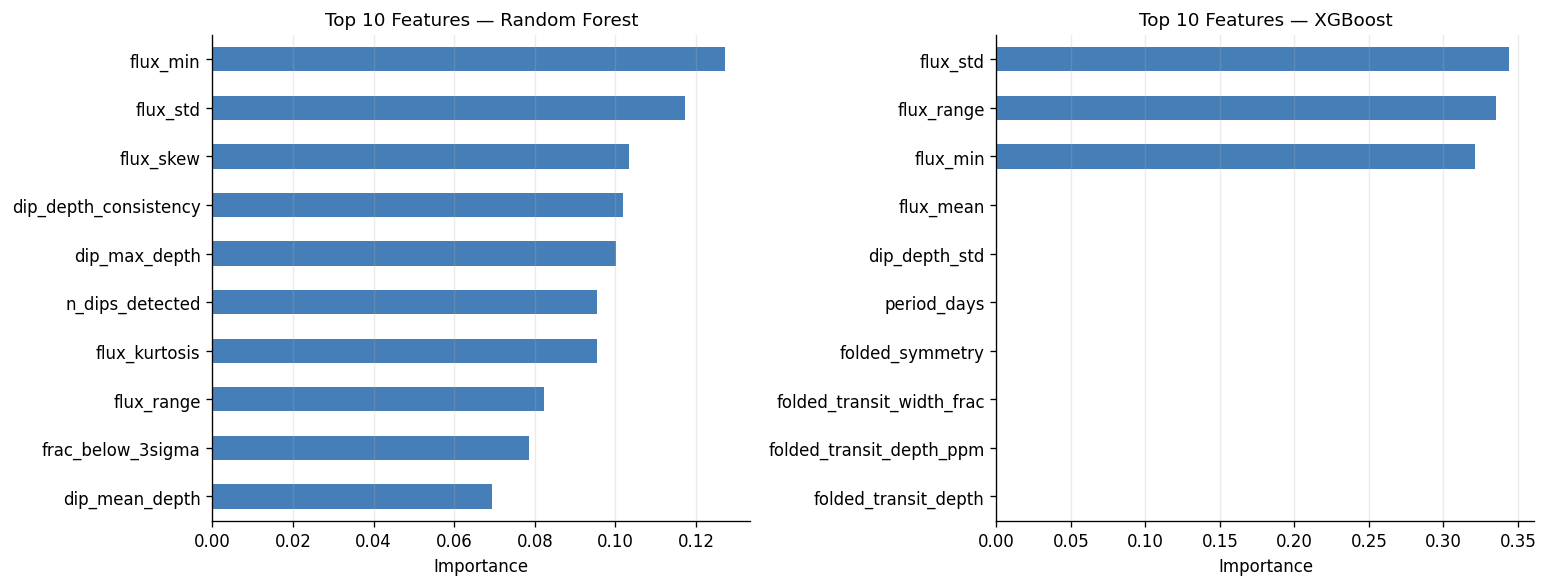

In [8]:
# ── Cell 7: Feature importance ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for model, name, ax in [(rf, "Random Forest", axes[0]), (xgb, "XGBoost", axes[1])]:
    imp = model.feature_importances().head(10)
    imp[::-1].plot(kind="barh", ax=ax, color="#185FA5", alpha=0.8)
    ax.set_title(f"Top 10 Features — {name}", fontsize=11, fontweight="normal")
    ax.set_xlabel("Importance", fontsize=10)
    ax.grid(True, axis="x", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [9]:
# ── Cell 8: Final test set evaluation ─────────────────────────────────────────
print("=" * 50)
print("FINAL TEST SET EVALUATION (held-out)")
print("=" * 50)

best_model = xgb if xgb_metrics["f1"] >= rf_metrics["f1"] else rf
best_name  = "XGBoost" if xgb_metrics["f1"] >= rf_metrics["f1"] else "Random Forest"
test_metrics = best_model.evaluate(X_test, y_test)

print_metrics(test_metrics, f"{best_name} (TEST SET)")
plot_confusion_matrix(y_test, best_model.predict(X_test), best_name).show() if False else None

print("\n📋 Update RESULTS.md with these numbers!")

FINAL TEST SET EVALUATION (held-out)
              precision    recall  f1-score   support

   No planet       1.00      1.00      1.00        66
      Planet       1.00      1.00      1.00         9

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75


────────────────────────────────────────
  Random Forest (TEST SET)
────────────────────────────────────────
  Precision        : 1.0000
  Recall           : 1.0000
  F1 Score         : 1.0000  ← primary metric
  ROC-AUC          : 1.0000
  PR-AUC           : 1.0000
────────────────────────────────────────

📋 Update RESULTS.md with these numbers!
